Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
import joblib

Data Loading

In [12]:

print("Loading Data for Naive Bayes...")
df = pd.read_csv("UNSW_NB15_training-set.csv")   # file is in same folder
X = df.drop(columns=['id', 'label', 'attack_cat'], errors='ignore')
y = df['label']
print("Data loaded successfully. Shape:", df.shape)


Loading Data for Naive Bayes...
Data loaded successfully. Shape: (82332, 45)


Preprocessing & Loading Scaler

In [13]:

print("Loading Data for Naive Bayes...")
df = pd.read_csv("UNSW_NB15_training-set.csv")   # no ../ needed
X = df.drop(columns=['id', 'label', 'attack_cat'], errors='ignore')
y = df['label']
print("Data loaded successfully. Shape:", df.shape)


Loading Data for Naive Bayes...
Data loaded successfully. Shape: (82332, 45)


Preprocessing & Loading Scaler

In [14]:
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

scaler = joblib.load('../models/scaler.pkl')
X_scaled = scaler.transform(X)


Naive Bayes Training & Serialization

In [15]:
print("Training Naive Bayes Model...")
nb = GaussianNB()
nb.fit(X_scaled, y)
joblib.dump(nb, '../models/nb_model.pkl')
print("Naive Bayes Model saved successfully.")

Training Naive Bayes Model...
Naive Bayes Model saved successfully.


ROC Curve Graph

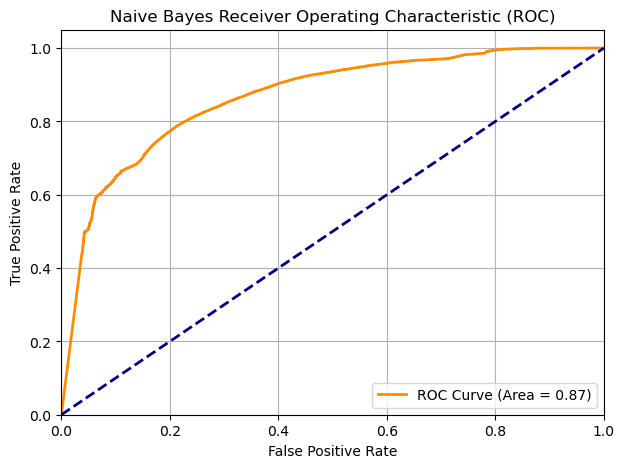

In [16]:

y_probs = nb.predict_proba(X_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (Area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Naive Bayes Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)